In [1]:
import darwinian_shift
import pandas as pd
from darwinian_shift import DarwinianShift
import seaborn as sns
import matplotlib.pyplot as plt
from darwinian_shift import BinomTest


import matplotlib

/Users/davidshorthouse/anaconda3/envs/dsenv/lib/python3.8/site-packages/MDAnalysis/coordinates/TRJ.py:1209: DeprecationWarning: Please use `netcdf_file` from the `scipy.io` namespace, the `scipy.io.netcdf` namespace is deprecated.
  class NCDFPicklable(scipy.io.netcdf.netcdf_file):
/Users/davidshorthouse/anaconda3/envs/dsenv/lib/python3.8/site-packages/Bio/pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


In [2]:
data = pd.read_excel("./Milan_muts_wolowcoverage.xlsx")

In [9]:
CROSS_mutation_data = data[data["Group"] == "CROSS"]
FLOT_mutation_data = data[data["Group"] == "FLOT"]
NT_mutation_data = data[data["Group"] == "NT"]
ECX_mutation_data = data[data["Group"] == "ECX"]
EOX_mutation_data = data[data["Group"] == "EOX"]


In [10]:
#CROSS_mutation_data = pd.read_csv("../CROSS_mutations.csv")
#FLOT_mutation_data = pd.read_csv("../FLOT_mutations.csv")
#NT_mutation_data = pd.read_csv("../NT_mutations.csv")
#ECX_mutation_data = pd.read_csv("../ECX_mutations.csv")
#EOX_mutation_data = pd.read_csv("../EOX_mutations.csv")

In [11]:
mutation_data_rac1 = NT_mutation_data[NT_mutation_data["gene"] == "RAC1"]
mutation_data_rac1_missense = mutation_data_rac1[mutation_data_rac1["summary"] == "missense"]
mutant_residues = mutation_data_rac1_missense["protein_desc"].str.extract('(\d+)')[0].tolist()

for item in mutation_data_rac1_missense["protein_desc"]:
    print(item)

p.P29L
p.P34S
p.P34S
p.P34R
p.Y64H
p.S71Y
p.P73L
p.R87Q
p.K135T
p.D137G
p.L196F


In [12]:
mutation_data_rac1 = FLOT_mutation_data[FLOT_mutation_data["gene"] == "RAC1"]
mutation_data_rac1_missense = mutation_data_rac1[mutation_data_rac1["summary"] == "missense"]
mutant_residues = mutation_data_rac1_missense["protein_desc"].str.extract('(\d+)')[0].tolist()

for item in mutation_data_rac1_missense["protein_desc"]:
    print(item)

p.V14L
p.I21V
p.I21L
p.I21V
p.N26I
p.P29L
p.D57H
p.D57G
p.V76I
p.V104L
p.N111Y
p.K135E
p.A163S


In [13]:
d_cross = DarwinianShift(
    data = CROSS_mutation_data,
    source_genome = "GRCh37",
    included_mutation_types = "missense")
print("Cross done")
#d_cross.spectra[0].write_to_file('../Spectra/CROSS_spectra.txt')

d_flot = DarwinianShift(
    data = FLOT_mutation_data,
    source_genome = "GRCh37",
    included_mutation_types = "missense")
print("FLOT done")

#d_flot.spectra[0].write_to_file('../Spectra/FLOT_spectra.txt')


d_nt = DarwinianShift(
    data = NT_mutation_data,
    source_genome = "GRCh37",
    included_mutation_types = "missense")
print("NT done")

#d_nt.spectra[0].write_to_file('../Spectra/NT_spectra.txt')

d_ecx = DarwinianShift(
    data = ECX_mutation_data,
    source_genome = "GRCh37",
    included_mutation_types = "missense")
print("ECX done")

d_eox = DarwinianShift(
    data = EOX_mutation_data,
    source_genome = "GRCh37",
    included_mutation_types = "missense")

print("EOX done")


In [14]:
from darwinian_shift import FoldXLookup

fold = FoldXLookup(foldx_results_directory = "./Foldx_results/",
                  sifts_directory = ".",
                  download_sifts=True)

In [15]:
d = {'CYS': 'C', 'ASP': 'D', 'SER': 'S', 'GLN': 'Q', 'LYS': 'K',
     'ILE': 'I', 'PRO': 'P', 'THR': 'T', 'PHE': 'F', 'ASN': 'N', 
     'GLY': 'G', 'HIS': 'H', 'LEU': 'L', 'ARG': 'R', 'TRP': 'W', 
     'ALA': 'A', 'VAL':'V', 'GLU': 'E', 'TYR': 'Y', 'MET': 'M'}

def shorten(x):
    if len(x) % 3 != 0: 
        raise ValueError('Input length should be a multiple of three')

    y = ''
    for i in range(len(x) // 3):
        y += d[x[3 * i : 3 * i + 3]]
    return y

def one_to_three(one_letter_code):
    mapping = {'A':'Ala',
               'R':'Arg',
               'N':'Asn',
               'D':'Asp',
               'C':'Cys',
               'Q':'Gln',
               'E':'Glu',
               'G':'Gly',
               'H':'His',
               'I':'Ile',
               'L':'Leu',
               'K':'Lys',
               'M':'Met',
               'F':'Phe',
               'P':'Pro',
               'S':'Ser',
               'T':'Thr',
               'W':'Trp',
               'Y':'Tyr',
               'V':'Val',}
    return mapping[one_letter_code.upper()].upper()


In [16]:
mutationdata = pd.read_csv("./Foldx_results/3TH5/chainA/RAC1_binding_DDG.csv", header = None)


converted_aa = []
for item in mutationdata[0]:
    aa = item[0]
    converted = one_to_three(aa)
    newitem = converted + item[1:]
    converted_aa.append(newitem)
    
mutationdata["converted"] = converted_aa
mutationdata = mutationdata.drop(0, axis =1)
mutationdata = mutationdata[["converted", 1]]
mutationdata[1] = mutationdata[1] * -1
mutationdata.head()

,converted,1
0,PROA29S,-0.14576
1,PROA29F,-0.12152
2,PROA29Y,-0.11555
3,PROA29A,-0.11452
4,PROA29I,0.34563


In [17]:
#mutationdata.to_csv("./Foldx_results/3TH5/chainA/PS_f0_scanning_output.txt", sep = "\t", header=False, index=False)

In [18]:
from darwinian_shift import MonteCarloTest
from darwinian_shift import CDFMonteCarloTest
import numpy as np

In [19]:
RAC1 = {
    "gene": "RAC1",
    "pdb_id": "3TH5",
    "pdb_chain": "A",
}

In [20]:
s_cross = d_cross.run_section(RAC1, lookup=fold, statistics = [MonteCarloTest(stat_function=np.mean, name = "MC_Mean"),
                                                                     MonteCarloTest(stat_function=np.median, name = "MC_Median"),
                                                                     CDFMonteCarloTest()])

In [21]:
s_cross.get_results_dictionary()

{'gene': 'RAC1',
 'transcript_id': 'ENST00000356142',
 'chrom': '7',
 'section_id': '3TH5:A',
 'num_mutations': 3,
 'observed_median': 0.11686,
 'observed_mean': 0.4048366666666667,
 'expected_median_glob_k3': -0.0,
 'median_shift_glob_k3': 0.11686,
 'expected_mean_glob_k3': 0.33903681373931965,
 'mean_shift_glob_k3': 0.06579985292734702,
 'MC_Mean_glob_k3_observed': 0.4048366666666667,
 'MC_Mean_glob_k3_null_mean': 0.3442858701,
 'MC_Mean_glob_k3_null_median': 0.14914383333333334,
 'MC_Mean_glob_k3_pvalue': 0.5763423657634237,
 'MC_Mean_glob_k3_num_smaller_or_equal': 7120,
 'MC_Mean_glob_k3_num_larger_or_equal': 2882,
 'MC_Median_glob_k3_observed': 0.11686,
 'MC_Median_glob_k3_null_mean': 0.1577654549,
 'MC_Median_glob_k3_null_median': 0.0,
 'MC_Median_glob_k3_pvalue': 0.5585441455854414,
 'MC_Median_glob_k3_num_smaller_or_equal': 7331,
 'MC_Median_glob_k3_num_larger_or_equal': 2793,
 'CDF_MC_glob_k3_num_smaller_or_equal': 8957,
 'CDF_MC_glob_k3_num_larger_or_equal': 1045,
 'CDF_MC_gl

In [22]:
s_flot = d_flot.run_section(RAC1, lookup=fold, statistics = [MonteCarloTest(stat_function=np.mean, name = "MC_Mean"),
                                                                     MonteCarloTest(stat_function=np.median, name = "MC_Median"),
                                                                     CDFMonteCarloTest()])

In [23]:
s_flot.get_results_dictionary()

{'gene': 'RAC1',
 'transcript_id': 'ENST00000356142',
 'chrom': '7',
 'section_id': '3TH5:A',
 'num_mutations': 7,
 'observed_median': -0.01179,
 'observed_mean': -1.144477142857143,
 'expected_median_glob_k3': 0.01587,
 'median_shift_glob_k3': -0.027659999999999997,
 'expected_mean_glob_k3': 0.376997860292813,
 'mean_shift_glob_k3': -1.521475003149956,
 'MC_Mean_glob_k3_observed': -1.144477142857143,
 'MC_Mean_glob_k3_null_mean': 0.37478272769999993,
 'MC_Mean_glob_k3_null_median': 0.22458450000000002,
 'MC_Mean_glob_k3_pvalue': 0.0029997000299970002,
 'MC_Mean_glob_k3_num_smaller_or_equal': 15,
 'MC_Mean_glob_k3_num_larger_or_equal': 9987,
 'MC_Median_glob_k3_observed': -0.01179,
 'MC_Median_glob_k3_null_mean': 0.10109773150000001,
 'MC_Median_glob_k3_null_median': 0.01587,
 'MC_Median_glob_k3_pvalue': 0.25437456254374563,
 'MC_Median_glob_k3_num_smaller_or_equal': 1272,
 'MC_Median_glob_k3_num_larger_or_equal': 8634,
 'CDF_MC_glob_k3_num_smaller_or_equal': 1144,
 'CDF_MC_glob_k3_num

In [24]:
s_nt = d_nt.run_section(RAC1, lookup=fold, statistics = [MonteCarloTest(stat_function=np.mean, name = "MC_Mean"),
                                                                     MonteCarloTest(stat_function=np.median, name = "MC_Median"),
                                                                     CDFMonteCarloTest()])

In [25]:
s_nt.get_results_dictionary()

{'gene': 'RAC1',
 'transcript_id': 'ENST00000356142',
 'chrom': '7',
 'section_id': '3TH5:A',
 'num_mutations': 2,
 'observed_median': -0.32849900000000004,
 'observed_mean': -0.32849900000000004,
 'expected_median_glob_k3': -0.0,
 'median_shift_glob_k3': -0.32849900000000004,
 'expected_mean_glob_k3': 0.33465949302935194,
 'mean_shift_glob_k3': -0.6631584930293519,
 'MC_Mean_glob_k3_observed': -0.32849900000000004,
 'MC_Mean_glob_k3_null_mean': 0.33674791085000005,
 'MC_Mean_glob_k3_null_median': 0.06008749999999999,
 'MC_Mean_glob_k3_pvalue': 0.29517048295170484,
 'MC_Mean_glob_k3_num_smaller_or_equal': 1476,
 'MC_Mean_glob_k3_num_larger_or_equal': 8526,
 'MC_Median_glob_k3_observed': -0.32849900000000004,
 'MC_Median_glob_k3_null_mean': 0.33151597974999997,
 'MC_Median_glob_k3_null_median': 0.060099999999999994,
 'MC_Median_glob_k3_pvalue': 0.2977702229777022,
 'MC_Median_glob_k3_num_smaller_or_equal': 1489,
 'MC_Median_glob_k3_num_larger_or_equal': 8513,
 'CDF_MC_glob_k3_num_smalle

In [26]:
s_ecx = d_ecx.run_section(RAC1, lookup=fold, statistics = [MonteCarloTest(stat_function=np.mean, name = "MC_Mean"),
                                                                     MonteCarloTest(stat_function=np.median, name = "MC_Median"),
                                                                     CDFMonteCarloTest()])

In [27]:
s_ecx.get_results_dictionary()

{'gene': 'RAC1',
 'transcript_id': 'ENST00000356142',
 'chrom': '7',
 'section_id': '3TH5:A',
 'num_mutations': 2,
 'observed_median': -0.018575,
 'observed_mean': -0.018575,
 'expected_median_glob_k3': 9e-05,
 'median_shift_glob_k3': -0.018665,
 'expected_mean_glob_k3': 0.30371860669375866,
 'mean_shift_glob_k3': -0.32229360669375867,
 'MC_Mean_glob_k3_observed': -0.018575,
 'MC_Mean_glob_k3_null_mean': 0.29827828295,
 'MC_Mean_glob_k3_null_median': 0.054425,
 'MC_Mean_glob_k3_pvalue': 0.7021297870212979,
 'MC_Mean_glob_k3_num_smaller_or_equal': 3511,
 'MC_Mean_glob_k3_num_larger_or_equal': 6489,
 'MC_Median_glob_k3_observed': -0.018575,
 'MC_Median_glob_k3_null_mean': 0.30727578565,
 'MC_Median_glob_k3_null_median': 0.057925,
 'MC_Median_glob_k3_pvalue': 0.7147285271472853,
 'MC_Median_glob_k3_num_smaller_or_equal': 3574,
 'MC_Median_glob_k3_num_larger_or_equal': 6428,
 'CDF_MC_glob_k3_num_smaller_or_equal': 3631,
 'CDF_MC_glob_k3_num_larger_or_equal': 6372,
 'CDF_MC_glob_k3_pvalue':

In [28]:
s_eox = d_eox.run_section(RAC1, lookup=fold, statistics = [MonteCarloTest(stat_function=np.mean, name = "MC_Mean"),
                                                                     MonteCarloTest(stat_function=np.median, name = "MC_Median"),
                                                                     CDFMonteCarloTest()])

NoMutationsError No mutations retained for 3TH5:A RAC1 - Unable to run for 3TH5:A


In [29]:
s_eox.get_results_dictionary()

AttributeError: 'NoneType' object has no attribute 'get_results_dictionary'

In [30]:
s_eox.get_pvalues()

AttributeError: 'NoneType' object has no attribute 'get_pvalues'

In [31]:
def plot_boxplot2(self, spectra=None, plot_scale=None, show_plot=False, colours=None,
                     figsize=(5, 5), return_fig=False, ax=None):
        """
        Boxplot of the expected and observed distributions of mutation scores.
        :param spectra: The mutational spectrum or list of mutational spectra to use.
        :param plot_scale:  Scale for the y-axis (mutation scores). Passed to matplotlib. 'log', 'symlog' etc.
        :param show_plot: If True, will call plt.show().
        :param colours: List of colours. First colour is for the observed data, the subsequent colours are
        for plotting the null distributions from each of the mutational spectra given.
        :param figsize: Size of the figure.
        :param return_fig: If True, will return the figure. Used for testing.
        :param ax: Matplotlib axis to plot on. If None, will create a new figure.
        :return: By default, None. If return_fig=True, will return the figure.
        """
#        if ax is None:
#            fig, ax = plt.subplots(figsize=figsize)
#        else:
#            fig = ax.figure

        spectra = self._get_spectra(spectra)

        colours = self._get_plot_colours(colours, len(spectra)+1)
        data = [get_distribution_from_mutational_spectrum(self.null_scores,
                                                          self.null_mutations[spectrum.rate_column])
                for spectrum in spectra]
        data.append(self.observed_values)
        
        return(data)

In [32]:
def get_distribution_from_mutational_spectrum(values, mut_rates, num=1000000):
    mut_rates = np.array(mut_rates)
    weights = mut_rates / mut_rates.sum()
    dist = np.repeat(values, np.random.multinomial(num, weights))
    return dist

In [33]:
data_cross = plot_boxplot2(s_cross)
data_flot = plot_boxplot2(s_flot)
data_nt= plot_boxplot2(s_nt)
data_ecx = plot_boxplot2(s_ecx)


basedistcross = data_cross[0]
crossdist = data_cross[1]
basedistflot = data_flot[0]
flotdist = data_flot[1]
basedistnt = data_flot[0]
ntdist = data_nt[1]
basedistecx = data_ecx[0]
ecxdist = data_ecx[1]

basedistcross = pd.DataFrame(basedistcross)
basedistcross["label"] = "base_cross"
basedistcross.columns = ["score", "label"]

basedistflot = pd.DataFrame(basedistflot)
basedistflot["label"] = "base_flot"
basedistflot.columns = ["score", "label"]

basedistnt = pd.DataFrame(basedistnt)
basedistnt["label"] = "base_nt"
basedistnt.columns = ["score", "label"]

basedistecx = pd.DataFrame(basedistecx)
basedistecx["label"] = "base_ecx"
basedistecx.columns = ["score", "label"]

crossdist = pd.DataFrame(crossdist)
crossdist["label"] = "cross"

flotdist = pd.DataFrame(flotdist)
flotdist["label"] = "flot"

ntdist = pd.DataFrame(ntdist)
ntdist["label"] = "nt"

ecxdist = pd.DataFrame(ecxdist)
ecxdist["label"] = "ecx"

testdist_cross = pd.DataFrame([-15])
testdist_cross["label"] = "base_cross"
testdist_cross.columns = ["score", "label"]

testdist_flot = pd.DataFrame([-15])
testdist_flot["label"] = "base_flot"
testdist_flot.columns = ["score", "label"]

testdist_nt = pd.DataFrame([-15])
testdist_nt["label"] = "base_nt"
testdist_nt.columns = ["score", "label"]

testdist_ecx = pd.DataFrame([-15])
testdist_ecx["label"] = "base_ecx"
testdist_ecx.columns = ["score", "label"]

combined = pd.concat([basedistcross, crossdist, basedistflot, flotdist,basedistnt, ntdist,
                     basedistecx, ecxdist], axis =0)
combined2 = pd.concat([testdist_cross, crossdist,testdist_flot, flotdist,testdist_nt, ntdist,
                      testdist_ecx, ecxdist], axis =0)

/var/folders/vv/0521912d5_j4wpw2lwprbrzw0000gn/T/ipykernel_78323/1028269640.py:45: UserWarning: FixedFormatter should only be used together with FixedLocator
  g.set_yticklabels(g.get_yticklabels(), size = 14)


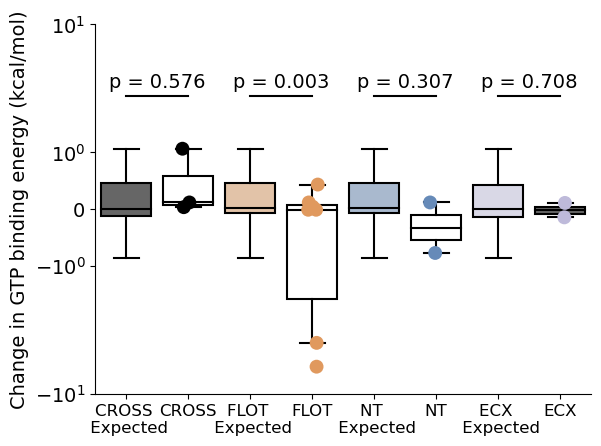

In [35]:
fig, ax = plt.subplots()

PROPS = {
    'boxprops':{'facecolor':'none', 'edgecolor':'black'},
    'medianprops':{'color':'black'},
    'whiskerprops':{'color':'black'},
    'capprops':{'color':'black'}
}


g = sns.boxplot(data = combined, x = "label", y = "score"
                , palette = ["k", "w", "#E0995E", "w", "#668AB8", "w","#bebada"], showfliers = False)
for patch in ax.patches:
    r, g1, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g1, b, 0.6))

g2 = sns.stripplot(data = combined2, x = "label", y = "score", palette=["w", "k","w", "#E0995E","w", "#668AB8", "w", "#bebada"], size = 10)

x1, x2 = 0, 1  
y, h, col = 2, 0, 'k'
plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c=col)
plt.text((x1+x2)*.5, y+h+0.2, "p = 0.576", ha='center', va='bottom', color=col, size = 14)


x1, x2 = 2, 3  
y, h, col = 2, 0, 'k'
plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c=col)
plt.text((x1+x2)*.5, y+h+0.2, "p = 0.003", ha='center', va='bottom', color=col, size = 14)

x1, x2 = 4, 5  
y, h, col = 2, 0, 'k'
plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c=col)
plt.text((x1+x2)*.5, y+h+0.2, "p = 0.307", ha='center', va='bottom', color=col, size = 14)

x1, x2 = 6, 7  
y, h, col = 2, 0, 'k'
plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c=col)
plt.text((x1+x2)*.5, y+h+0.2, "p = 0.708", ha='center', va='bottom', color=col, size = 14)


g.set_xlabel("")
g.set_xticklabels(["CROSS \n Expected", "CROSS", "FLOT \n Expected", "FLOT", "NT \n Expected", "NT", "ECX \n Expected", "ECX"], size = 12)

g.set_ylabel("Change in GTP binding energy (kcal/mol)", size = 14)
g.set_yticklabels(g.get_yticklabels(), size = 14)
ax.set_yscale("symlog")
ax.set_ylim(-10, 10)
sns.despine()

plt.savefig("RAC1_ATPbindingenergy_v3.pdf", bbox_inches = "tight")

In [36]:
from darwinian_shift import StructureDistanceLookup

atpdist = StructureDistanceLookup(target_key = "target_selection", distance_to_alpha_carbons=True,
                                 sifts_directory = ".", pdb_directory=".")

In [37]:
RAC1_dist = {
    "gene": "RAC1",
    "pdb_id": "3TH5",
    "pdb_chain": "A",
    "target_selection":"chainID A and resname GNP"}

In [38]:
s_dist_cross = d_cross.run_section(RAC1_dist, lookup=atpdist, statistics = [MonteCarloTest(stat_function=np.mean, name = "MC_Mean"),
                                                                     MonteCarloTest(stat_function=np.median, name = "MC_Median"),
                                                                     CDFMonteCarloTest()])

In [39]:
s_dist_cross.get_pvalues()

{'MC_Mean_glob_k3_pvalue': 0.2465753424657534,
 'MC_Median_glob_k3_pvalue': 0.5781421857814218,
 'CDF_MC_glob_k3_pvalue': 0.2663733626637336}

In [40]:
s_dist_flot = d_flot.run_section(RAC1_dist, lookup=atpdist, statistics = [MonteCarloTest(stat_function=np.mean, name = "MC_Mean"),
                                                                     MonteCarloTest(stat_function=np.median, name = "MC_Median"),
                                                                     CDFMonteCarloTest()])

In [41]:
s_dist_flot.get_pvalues()

{'MC_Mean_glob_k3_pvalue': 0.1347865213478652,
 'MC_Median_glob_k3_pvalue': 0.0231976802319768,
 'CDF_MC_glob_k3_pvalue': 0.11998800119988001}

In [42]:
s_dist_nt = d_nt.run_section(RAC1_dist, lookup=atpdist, statistics = [MonteCarloTest(stat_function=np.mean, name = "MC_Mean"),
                                                                     MonteCarloTest(stat_function=np.median, name = "MC_Median"),
                                                                     CDFMonteCarloTest()])

In [43]:
s_dist_nt.get_pvalues()

{'MC_Mean_glob_k3_pvalue': 0.141985801419858,
 'MC_Median_glob_k3_pvalue': 0.6723327667233276,
 'CDF_MC_glob_k3_pvalue': 0.18318168183181682}

In [44]:
s_dist_ecx = d_ecx.run_section(RAC1_dist, lookup=atpdist, statistics = [MonteCarloTest(stat_function=np.mean, name = "MC_Mean"),
                                                                     MonteCarloTest(stat_function=np.median, name = "MC_Median"),
                                                                     CDFMonteCarloTest()])

In [45]:
s_dist_ecx.get_pvalues()

{'MC_Mean_glob_k3_pvalue': 0.136986301369863,
 'MC_Median_glob_k3_pvalue': 0.38276172382761725,
 'CDF_MC_glob_k3_pvalue': 0.1065893410658934}

In [46]:
s_dist_eox = d_eox.run_section(RAC1_dist, lookup=atpdist, statistics = [MonteCarloTest(stat_function=np.mean, name = "MC_Mean"),
                                                                     MonteCarloTest(stat_function=np.median, name = "MC_Median"),
                                                                     CDFMonteCarloTest()])

In [47]:
s_dist_eox.get_pvalues()

{'MC_Mean_glob_k3_pvalue': 0.384961503849615,
 'MC_Median_glob_k3_pvalue': 0.39036096390360964,
 'CDF_MC_glob_k3_pvalue': 0.38776122387761225}

In [48]:
data_cross = plot_boxplot2(s_dist_cross)
data_flot = plot_boxplot2(s_dist_flot)
data_nt= plot_boxplot2(s_dist_nt)
data_ecx = plot_boxplot2(s_dist_ecx)
data_eox = plot_boxplot2(s_dist_eox)

basedistcross = data_cross[0]
crossdist = data_cross[1]
basedistflot = data_flot[0]
flotdist = data_flot[1]
basedistnt = data_flot[0]
ntdist = data_nt[1]
basedistecx = data_ecx[0]
ecxdist = data_ecx[1]
basedisteox = data_nt[0]
eoxdist = data_nt[1]

basedistcross = pd.DataFrame(basedistcross)
basedistcross["label"] = "base_cross"
basedistcross.columns = ["score", "label"]

basedistflot = pd.DataFrame(basedistflot)
basedistflot["label"] = "base_flot"
basedistflot.columns = ["score", "label"]

basedistnt = pd.DataFrame(basedistnt)
basedistnt["label"] = "base_nt"
basedistnt.columns = ["score", "label"]

basedistecx = pd.DataFrame(basedistecx)
basedistecx["label"] = "base_ecx"
basedistecx.columns = ["score", "label"]

basedisteox = pd.DataFrame(basedisteox)
basedisteox["label"] = "base_eox"
basedisteox.columns = ["score", "label"]

crossdist = pd.DataFrame(crossdist)
crossdist["label"] = "cross"

flotdist = pd.DataFrame(flotdist)
flotdist["label"] = "flot"

ntdist = pd.DataFrame(ntdist)
ntdist["label"] = "nt"

ecxdist = pd.DataFrame(ecxdist)
ecxdist["label"] = "ecx"

eoxdist = pd.DataFrame(eoxdist)
eoxdist["label"] = "eox"

testdist_cross = pd.DataFrame([-10])
testdist_cross["label"] = "base_cross"
testdist_cross.columns = ["score", "label"]

testdist_flot = pd.DataFrame([-10])
testdist_flot["label"] = "base_flot"
testdist_flot.columns = ["score", "label"]

testdist_nt = pd.DataFrame([-10])
testdist_nt["label"] = "base_nt"
testdist_nt.columns = ["score", "label"]

testdist_ecx = pd.DataFrame([-10])
testdist_ecx["label"] = "base_ecx"
testdist_ecx.columns = ["score", "label"]

testdist_eox = pd.DataFrame([-10])
testdist_eox["label"] = "base_eox"
testdist_eox.columns = ["score", "label"]

combined = pd.concat([basedistcross, crossdist, basedistflot, flotdist,basedistnt, ntdist,
                     basedistecx, ecxdist, basedisteox, eoxdist], axis =0)
combined2 = pd.concat([testdist_cross, crossdist,testdist_flot, flotdist,testdist_nt, ntdist,
                      testdist_ecx, ecxdist, testdist_eox, eoxdist], axis =0)

/var/folders/vv/0521912d5_j4wpw2lwprbrzw0000gn/T/ipykernel_78323/248790685.py:51: UserWarning: FixedFormatter should only be used together with FixedLocator
  g.set_yticklabels(g.get_yticklabels(), size = 14)
/var/folders/vv/0521912d5_j4wpw2lwprbrzw0000gn/T/ipykernel_78323/248790685.py:55: UserWarning: FixedFormatter should only be used together with FixedLocator
  g.set_yticklabels([0,5,10,15,20,25,30], size = 14)


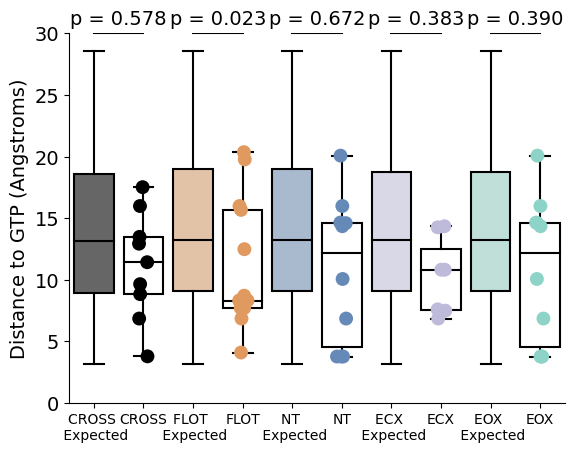

In [49]:
fig, ax = plt.subplots()

PROPS = {
    'boxprops':{'facecolor':'none', 'edgecolor':'black'},
    'medianprops':{'color':'black'},
    'whiskerprops':{'color':'black'},
    'capprops':{'color':'black'}
}


g = sns.boxplot(data = combined, x = "label", y = "score"
                , palette = ["k", "w", "#E0995E", "w", "#668AB8", "w", "#bebada", "w", "#8dd3c7", "w"], showfliers = False)
for patch in ax.patches:
    r, g1, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g1, b, 0.6))

g2 = sns.stripplot(data = combined2, x = "label", y = "score", palette=["w", "k","w", "#E0995E","w", "#668AB8", "w", "#bebada", "w", "#8dd3c7"], size = 10)

x1, x2 = 0, 1  
y, h, col = 30, 0, 'k'
plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c=col)
plt.text((x1+x2)*.5, y+h+0.4, "p = %.3f" % s_dist_cross.get_pvalues()["MC_Median_glob_k3_pvalue"], ha='center', va='bottom', color=col, size = 14)


x1, x2 = 2, 3  
y, h, col = 30, 0, 'k'
plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c=col)
plt.text((x1+x2)*.5, y+h+0.4, "p = %.3f" % s_dist_flot.get_pvalues()["MC_Median_glob_k3_pvalue"], ha='center', va='bottom', color=col, size = 14)

x1, x2 = 4, 5  
y, h, col = 30, 0, 'k'
plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c=col)
plt.text((x1+x2)*.5, y+h+0.4, "p = %.3f" % s_dist_nt.get_pvalues()["MC_Median_glob_k3_pvalue"], ha='center', va='bottom', color=col, size = 14)

x1, x2 = 6, 7  
y, h, col = 30, 0, 'k'
plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c=col)
plt.text((x1+x2)*.5, y+h+0.4, "p = %.3f" % s_dist_ecx.get_pvalues()["MC_Median_glob_k3_pvalue"], ha='center', va='bottom', color=col, size = 14)

x1, x2 = 8, 9  
y, h, col = 30, 0, 'k'
plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c=col)
plt.text((x1+x2)*.5, y+h+0.4, "p = %.3f" % s_dist_eox.get_pvalues()["MC_Median_glob_k3_pvalue"], ha='center', va='bottom', color=col, size = 14)


g.set_xlabel("")
g.set_xticklabels(["CROSS \n Expected", "CROSS", "FLOT \n Expected", "FLOT", "NT \n Expected", "NT"
                   , "ECX \n Expected", "ECX", "EOX \n Expected", "EOX"], size = 10)

g.set_ylabel("Distance to GTP (Angstroms)", size = 14)
g.set_yticklabels(g.get_yticklabels(), size = 14)
ax.set_ylim(0, 30)
sns.despine()

g.set_yticklabels([0,5,10,15,20,25,30], size = 14)

#plt.savefig("RAC1_distancetoGTP_v2.pdf")
plt.show()

In [86]:
s_dist_cross.get_pvalues()

{'MC_Mean_glob_k3_pvalue': 0.09859014098590141,
 'MC_Median_glob_k3_pvalue': 0.27977202279772023,
 'CDF_MC_glob_k3_pvalue': 0.12258774122587741}

In [87]:
s_dist_flot.get_pvalues()

{'MC_Mean_glob_k3_pvalue': 0.12538746125387462,
 'MC_Median_glob_k3_pvalue': 0.025197480251974803,
 'CDF_MC_glob_k3_pvalue': 0.12058794120587941}

In [88]:
s_dist_nt.get_pvalues()

{'MC_Mean_glob_k3_pvalue': 0.14658534146585342,
 'MC_Median_glob_k3_pvalue': 0.6711328867113289,
 'CDF_MC_glob_k3_pvalue': 0.1867813218678132}

## Hinge analysis

In [50]:
from Bio.PDB import PDBParser, NeighborSearch, Selection
from Bio.PDB import PDBParser, NeighborSearch

def find_residues_within_cutoff(pdb_file, chain_id, residue_numbers, cutoff=5.0):
    """
    Identify residues within a cutoff distance of a list of target residues in a protein structure.

    :param pdb_file: Path to the PDB file.
    :param chain_id: Chain ID of the target residues.
    :param residue_numbers: List of residue numbers in the specified chain.
    :param cutoff: Cutoff distance in angstroms.
    :return: Set of residues within the cutoff distance.
    """
    # Parse the PDB file
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure("protein", pdb_file)
    
    # Flatten all atoms in the structure for NeighborSearch
    atoms = [atom for atom in structure.get_atoms()]
    ns = NeighborSearch(atoms)
    
    # Collect target atoms based on target residues
    target_atoms = []
    for chain in structure[0]:
        if chain.id == chain_id:
            for residue in chain:
                if residue.id[1] in residue_numbers:
                    target_atoms.extend(residue.get_atoms())
    
    # Find nearby atoms
    nearby_atoms = set()
    for atom in target_atoms:
        nearby_atoms.update(ns.search(atom.coord, cutoff))
    
    # Convert nearby atoms to residues
    nearby_residues = set()
    for atom in nearby_atoms:
        residue = atom.get_parent()
        chain_id = residue.get_full_id()[2]
        residue_number = residue.id[1]
        nearby_residues.add((chain_id, residue_number))
    
    return nearby_residues

# Example usage
if __name__ == "__main__":
    pdb_file = "5n6o.pdb"  # Replace with your PDB file
    target_residues = [4, 21, 23, 38, 53, 74, 82, 85, 114, 136, 161]  # Replace with your target residues (chain, residue number)
    cutoff = 4.2  # Replace with your desired cutoff distance
    chain_id = "A"
    
    
    residues = find_residues_within_cutoff(pdb_file, chain_id, target_residues, cutoff)
    print("Residues within cutoff:")
    residuelist = []
    for chain_id, residue_number in sorted(residues):
        residuelist.append(residue_number)
        print(f"Chain {chain_id}, Residue {residue_number}")


FileNotFoundError: [Errno 2] No such file or directory: '5n6o.pdb'

In [51]:
RAC1_switch1 = {
    'gene': 'RAC1',
    'pdb_id': '5N6O', 
    'pdb_chain': 'A',
    'start': 28,
    'end': 38
}

RAC1_gene = {
    'gene': 'RAC1',
    'pdb_id': '5N6O', 
    'pdb_chain': 'A'
}

RAC1_gene['switch1'] = [
     32, 33, 34, 35, 36, 37, 38
]

RAC1_gene['switch2'] = [
     59, 60, 61, 62, 63, 64, 65, 66, 67
]

RAC1_gene["GNM_mode0"] = [
    8, 14, 17, 78, 95, 110, 147, 152, 163
]

RAC1_gene["GNM_mode1"] = [
    4, 21, 23, 38, 53, 74, 82, 85, 114, 136, 161
]

RAC1_gene["GNM_mode2"] = [
    6, 10, 41, 52, 56, 57, 82, 112, 120, 153, 168
]

RAC1_gene["GNM_mode1_vicinity"] = residuelist


from darwinian_shift import SequenceDistanceLookup
interface_lookup = StructureDistanceLookup(
    distance_to_alpha_carbons = True,   # Just a boolean on/off interface. 
    target_key='GNM_mode1',   # Use this entry in the region dict below to define the target residues
       # Use the residue number (as opposed to cdspos or chromosomal position)
)


from darwinian_shift import SequenceDistanceLookup
switch1_lookup = StructureDistanceLookup(
    distance_to_alpha_carbons = True,   # Just a boolean on/off interface. 
    target_key='switch1',   # Use this entry in the region dict below to define the target residues
       # Use the residue number (as opposed to cdspos or chromosomal position)
)

from darwinian_shift import SequenceDistanceLookup
switch2_lookup = StructureDistanceLookup(
    distance_to_alpha_carbons = True,   # Just a boolean on/off interface. 
    target_key='switch2',   # Use this entry in the region dict below to define the target residues
       # Use the residue number (as opposed to cdspos or chromosomal position)
)



NameError: name 'residuelist' is not defined

In [52]:
from darwinian_shift import SequenceDistanceLookup
interface_lookup = SequenceDistanceLookup(
    boolean=True,   # Just a boolean on/off interface. 
    target_key='GNM_mode1_vicinity',   # Use this entry in the region dict below to define the target residues
    position_type='residue',   # Use the residue number (as opposed to cdspos or chromosomal position)
)

In [53]:
s_nt = d_nt.run_section(
    RAC1_gene, 
    lookup=interface_lookup, 
    statistics=BinomTest()   # Here we specify the statistical test to use
)

ValueError: Target selection GNM_mode1_vicinity not defined for section 5N6O:A

In [ ]:
s_nt.get_pvalues()

In [54]:
s_nt.get_results_dictionary()

{'gene': 'RAC1',
 'transcript_id': 'ENST00000356142',
 'chrom': '7',
 'section_id': '3TH5:A',
 'num_mutations': 2,
 'observed_median': -0.32849900000000004,
 'observed_mean': -0.32849900000000004,
 'expected_median_glob_k3': -0.0,
 'median_shift_glob_k3': -0.32849900000000004,
 'expected_mean_glob_k3': 0.33465949302935194,
 'mean_shift_glob_k3': -0.6631584930293519,
 'MC_Mean_glob_k3_observed': -0.32849900000000004,
 'MC_Mean_glob_k3_null_mean': 0.33674791085000005,
 'MC_Mean_glob_k3_null_median': 0.06008749999999999,
 'MC_Mean_glob_k3_pvalue': 0.29517048295170484,
 'MC_Mean_glob_k3_num_smaller_or_equal': 1476,
 'MC_Mean_glob_k3_num_larger_or_equal': 8526,
 'MC_Median_glob_k3_observed': -0.32849900000000004,
 'MC_Median_glob_k3_null_mean': 0.33151597974999997,
 'MC_Median_glob_k3_null_median': 0.060099999999999994,
 'MC_Median_glob_k3_pvalue': 0.2977702229777022,
 'MC_Median_glob_k3_num_smaller_or_equal': 1489,
 'MC_Median_glob_k3_num_larger_or_equal': 8513,
 'CDF_MC_glob_k3_num_smalle

In [55]:
s_flot = d_flot.run_section(
    RAC1_gene, 
    lookup=interface_lookup, 
    statistics=BinomTest()   # Here we specify the statistical test to use
)

ValueError: Target selection GNM_mode1_vicinity not defined for section 5N6O:A

In [96]:
s_flot.get_results_dictionary()

{'gene': 'RAC1',
 'transcript_id': 'ENST00000356142',
 'chrom': '7',
 'section_id': '5N6O:A',
 'num_mutations': 13,
 'observed_median': 1.0,
 'observed_mean': 0.8461538461538461,
 'expected_median_glob_k3': 0.0,
 'median_shift_glob_k3': 1.0,
 'expected_mean_glob_k3': 0.38850567972159056,
 'mean_shift_glob_k3': 0.4576481664322556,
 'binom_glob_k3_pvalue': 0.0009862566025423754,
 'binom_glob_k3_expected_proportion': 0.38850567972159056,
 'binom_glob_k3_observed_proportion': 0.8461538461538461,
 'binom_glob_k3_expected_count': 5.050573836380678,
 'binom_glob_k3_observed_count': 11,
 'binom_glob_k3_threshold': 0.5,
 'binom_glob_k3_expected_CI_high': 9.0,
 'binom_glob_k3_expected_CI_low': 2.0,
 'binom_glob_k3_observed_CI_low': 8.0,
 'binom_glob_k3_observed_CI_high': 13.0}

In [97]:
s_nt.get_observed_mutations_in_region()["aachange"]

3      P29L
5      P34S
8      P34R
9      P34S
6      Y64H
1      S71Y
10     P73L
7      R87Q
0     K135T
2     D137G
4     L196F
Name: aachange, dtype: object

In [98]:
s_flot.get_pvalues()

{'binom_glob_k3_pvalue': 0.0009862566025423754}

In [99]:
s_cross = d_cross.run_section(
    RAC1_gene, 
    lookup=interface_lookup, 
    statistics=BinomTest()   # Here we specify the statistical test to use
)

In [100]:
s_cross.get_pvalues()

{'binom_glob_k3_pvalue': 0.202487795139127}

In [101]:
s_cross.get_results_dictionary()

{'gene': 'RAC1',
 'transcript_id': 'ENST00000356142',
 'chrom': '7',
 'section_id': '5N6O:A',
 'num_mutations': 10,
 'observed_median': 1.0,
 'observed_mean': 0.6,
 'expected_median_glob_k3': 0.0,
 'median_shift_glob_k3': 1.0,
 'expected_mean_glob_k3': 0.3897110783109083,
 'mean_shift_glob_k3': 0.2102889216890917,
 'binom_glob_k3_pvalue': 0.202487795139127,
 'binom_glob_k3_expected_proportion': 0.3897110783109082,
 'binom_glob_k3_observed_proportion': 0.6,
 'binom_glob_k3_expected_count': 3.8971107831090817,
 'binom_glob_k3_observed_count': 6,
 'binom_glob_k3_threshold': 0.5,
 'binom_glob_k3_expected_CI_high': 7.0,
 'binom_glob_k3_expected_CI_low': 1.0,
 'binom_glob_k3_observed_CI_low': 3.0,
 'binom_glob_k3_observed_CI_high': 9.0}

In [102]:
s_ecx = d_ecx.run_section(
    RAC1_gene, 
    lookup=interface_lookup, 
    statistics=BinomTest()   # Here we specify the statistical test to use
)

In [103]:
s_ecx.get_results_dictionary()

{'gene': 'RAC1',
 'transcript_id': 'ENST00000356142',
 'chrom': '7',
 'section_id': '5N6O:A',
 'num_mutations': 7,
 'observed_median': 0.0,
 'observed_mean': 0.42857142857142855,
 'expected_median_glob_k3': 0.0,
 'median_shift_glob_k3': 0.0,
 'expected_mean_glob_k3': 0.3861783141225433,
 'mean_shift_glob_k3': 0.04239311444888527,
 'binom_glob_k3_pvalue': 1.0,
 'binom_glob_k3_expected_proportion': 0.38617831412254333,
 'binom_glob_k3_observed_proportion': 0.42857142857142855,
 'binom_glob_k3_expected_count': 2.7032481988578034,
 'binom_glob_k3_observed_count': 3,
 'binom_glob_k3_threshold': 0.5,
 'binom_glob_k3_expected_CI_high': 5.0,
 'binom_glob_k3_expected_CI_low': 0.0,
 'binom_glob_k3_observed_CI_low': 1.0,
 'binom_glob_k3_observed_CI_high': 6.0}

In [104]:
s_eox = d_eox.run_section(
    RAC1_gene, 
    lookup=interface_lookup, 
    statistics=BinomTest()   # Here we specify the statistical test to use
)

In [105]:
s_eox.get_results_dictionary()

{'gene': 'RAC1',
 'transcript_id': 'ENST00000356142',
 'chrom': '7',
 'section_id': '5N6O:A',
 'num_mutations': 1,
 'observed_median': 0.0,
 'observed_mean': 0.0,
 'expected_median_glob_k3': 0.0,
 'median_shift_glob_k3': 0.0,
 'expected_mean_glob_k3': 0.39176975072604586,
 'mean_shift_glob_k3': -0.39176975072604586,
 'binom_glob_k3_pvalue': 1.0,
 'binom_glob_k3_expected_proportion': 0.39176975072604586,
 'binom_glob_k3_observed_proportion': 0.0,
 'binom_glob_k3_expected_count': 0.39176975072604586,
 'binom_glob_k3_observed_count': 0,
 'binom_glob_k3_threshold': 0.5,
 'binom_glob_k3_expected_CI_high': 1.0,
 'binom_glob_k3_expected_CI_low': 0.0,
 'binom_glob_k3_observed_CI_low': 0.0,
 'binom_glob_k3_observed_CI_high': 0.0}

In [106]:
s_eox.get_pvalues()

{'binom_glob_k3_pvalue': 1.0}

In [107]:
samples = [0,1,2,3,4,5,6,7,8,9]
results_list = [3.90, 6.0, 5.05, 11, 4.26, 8, 2.7,3, 0.39, 0]

# Split into pairs and assign group labels
group_labels = ['Group A', 'Group B'] * (len(results_list) // 2)
pair_labels = [f'Pair {i//2 + 1}' for i in range(len(results_list))]

# Create a DataFrame for plotting
data = {
    'Pair': pair_labels,
    'Group': group_labels,
    'Value': results_list
}

paired_data = pd.DataFrame(data)

paired_data.head()

,Pair,Group,Value
0,Pair 1,Group A,3.90
1,Pair 1,Group B,6.00
2,Pair 2,Group A,5.05
3,Pair 2,Group B,11.00
4,Pair 3,Group A,4.26


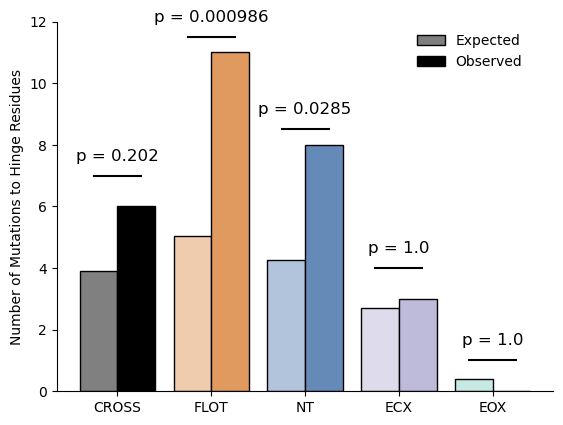

In [108]:
from matplotlib.patches import Patch


palette = ["#000000", "#000000", "#E0995E","#E0995E", "#668AB8","#668AB8", "#bebada","#bebada", "#8dd3c7","#8dd3c7"]

# Function to add alpha to a hex color
def add_alpha_to_hex(hex_color, alpha):
    if hex_color.startswith("#"):
        # Convert alpha from [0, 1] to hexadecimal (00 to FF)
        alpha_hex = f"{int(alpha * 255):02X}"
        return hex_color + alpha_hex
    elif hex_color == "k":  # Handle shorthand for black ('k') by expanding it to #000000
        alpha_hex = f"{int(alpha * 255):02X}"
        return "#000000" + alpha_hex
    return hex_color

# Adjust palette to alternate alpha values
adjusted_palette = [
    add_alpha_to_hex(color, 0.5 if i % 2 == 0 else 1.0) for i, color in enumerate(palette)
]


g = sns.barplot(x = paired_data["Pair"], y = paired_data["Value"], hue = paired_data["Group"]
                , lw = 1, edgecolor = "k", palette = adjusted_palette)

for bars, colors in zip(g.containers, (adjusted_palette[0::2], adjusted_palette[1::2])):
     for bar, color in zip(bars, colors):
          bar.set_facecolor(color)
        
legend_elements = [
    Patch(facecolor="#00000080", edgecolor='k', label='Expected'),
    Patch(facecolor="#000000FF", edgecolor='k', label='Observed')
]
# Add the custom legend
plt.legend(
    handles=legend_elements,
    bbox_to_anchor=(0.7, 1),  # Position outside the plot
    loc='upper left',
    frameon = False
)

g.set_ylabel("Number of Mutations to Hinge Residues")

g.set_xlabel("")
g.set_xticklabels(["CROSS", "FLOT", "NT", "ECX", "EOX"])

g.set_ylim(0,12)


x1, x2 = -0.25, 0.25
y, h, col = 7, 0, 'k'
plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c=col)
plt.text((x1+x2)*.5, y+h+0.4, "p = 0.202", ha='center', va='bottom', color=col, size = 12)

x1, x2 = 0.75, 1.25
y, h, col = 11.5, 0, 'k'
plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c=col)
plt.text((x1+x2)*.5, y+h+0.4, "p = 0.000986", ha='center', va='bottom', color=col, size = 12)

x1, x2 = 1.75, 2.25
y, h, col = 8.5, 0, 'k'
plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c=col)
plt.text((x1+x2)*.5, y+h+0.4, "p = 0.0285", ha='center', va='bottom', color=col, size = 12)


x1, x2 = 2.75, 3.25
y, h, col = 4, 0, 'k'
plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c=col)
plt.text((x1+x2)*.5, y+h+0.4, "p = 1.0", ha='center', va='bottom', color=col, size = 12)


x1, x2 = 3.75, 4.25
y, h, col = 1, 0, 'k'
plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c=col)
plt.text((x1+x2)*.5, y+h+0.4, "p = 1.0", ha='center', va='bottom', color=col, size = 12)

sns.despine()

plt.savefig("Hinge_binomial_v1.pdf")

In [280]:
4%2

0

## SASA

In [295]:
RAC1 = {
    "gene": "RAC1",
    "pdb_id": "3TH5",
    "pdb_chain": "A",
}

In [296]:
from darwinian_shift import FreeSASALookup

sasa = FreeSASALookup(metric = "relativeTotal", sifts_directory = ".", pdb_directory=".", download_pdb_file=True)

In [339]:
RAC1_dist = {
    "gene": "RAC1",
    "pdb_id": "3TH5",
    "pdb_chain": "A",
    "target_selection":"chainID A and resid 55 66 28 38"}
RAC1_dist = {
    "gene": "RAC1",
    "pdb_id": "3TH5",
    "pdb_chain": "A",
    "pak1_interface":"chainID A and resid 20 21 23 24 25 27 31 33 34 36 37 38 39 40 41 42 43 44 45 46 47 56 58 63 64 66 67 70 165 166 169 170 173 174"}

# from https://www.sciencedirect.com/science/article/pii/S0006349521000539

In [351]:
from darwinian_shift import StructureDistanceLookup

distance = StructureDistanceLookup(target_key = "pak1_interface", 
                                   boolean = True,
                                 sifts_directory = ".", pdb_directory = ".")

In [362]:
s3_flot = d_flot.run_section(RAC1_dist, lookup=distance, statistics = BinomTest())
s3_cross = d_cross.run_section(RAC1_dist, lookup=distance, statistics = BinomTest())
s3_nt = d_nt.run_section(RAC1_dist, lookup=distance, statistics = BinomTest())

In [363]:
s3_flot.get_pvalues()

{'binom_glob_k3_pvalue': 0.4458542742418104}

In [364]:
s3_cross.get_pvalues()

{'binom_glob_k3_pvalue': 0.6930897618347265}

In [365]:
s3_nt.get_pvalues()

{'binom_glob_k3_pvalue': 0.06413086058622294}

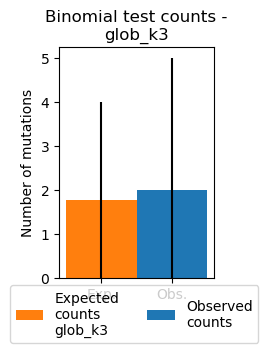

In [369]:
s3_cross.plot_binomial()

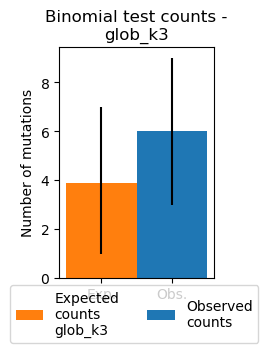

In [228]:
s_cross.plot_binomial()

In [357]:
data_cross = plot_boxplot2(s3_cross)
data_flot = plot_boxplot2(s3_flot)
data_nt= plot_boxplot2(s3_nt)

basedist = data_cross[0]
crossdist = data_cross[1]
flotdist = data_flot[1]
ntdist = data_nt[1]

basedist = pd.DataFrame(basedist)
basedist["label"] = "base"
basedist.columns = ["score", "label"]

crossdist = pd.DataFrame(crossdist)
crossdist["label"] = "cross"

flotdist = pd.DataFrame(flotdist)
flotdist["label"] = "flot"

ntdist = pd.DataFrame(ntdist)
ntdist["label"] = "nt"

testdist = pd.DataFrame([2])
testdist["label"] = "base"
testdist.columns = ["score", "label"]

combined = pd.concat([basedist, crossdist, flotdist, ntdist], axis =0)
combined2 = pd.concat([testdist, crossdist, flotdist, ntdist], axis =0)

/var/folders/d9/4lyh6rdd5mdbxby_y5lwsy180000gn/T/ipykernel_67388/3373865264.py:33: UserWarning: FixedFormatter should only be used together with FixedLocator
  g.set_yticklabels([0,5,10,15,20,25,30,35,40], size = 14)


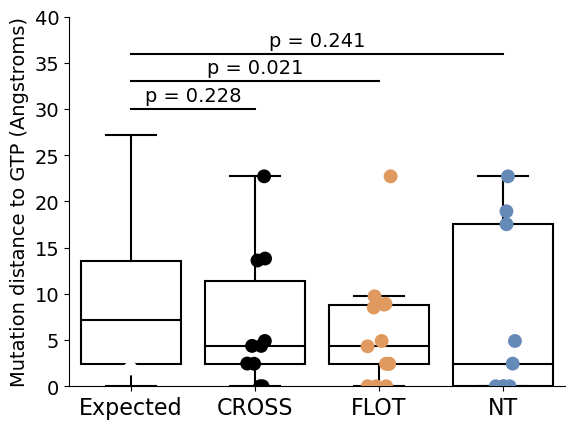

In [348]:
fig, ax = plt.subplots()

PROPS = {
    'boxprops':{'facecolor':'none', 'edgecolor':'black'},
    'medianprops':{'color':'black'},
    'whiskerprops':{'color':'black'},
    'capprops':{'color':'black'}
}

g = sns.boxplot(data = combined, x = "label", y = "score", palette = ["w"], ** PROPS, showfliers = False)
g2 = sns.stripplot(data = combined2, x = "label", y = "score", palette=["w", "k", "#E0995E", "#668AB8"], size = 10)

x1, x2 = 0, 1  
y, h, col = 30, 0, 'k'
plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c=col)
plt.text((x1+x2)*.5, y+h+0.4, "p = 0.228", ha='center', va='bottom', color=col, size = 14)


x1, x2 = 0, 2  
y, h, col = 33, 0, 'k'
plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c=col)
plt.text((x1+x2)*.5, y+h+0.4, "p = 0.021", ha='center', va='bottom', color=col, size = 14)

x1, x2 = 0, 3  
y, h, col = 36, 0, 'k'
plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c=col)
plt.text((x1+x2)*.5, y+h+0.4, "p = 0.241", ha='center', va='bottom', color=col, size = 14)

g.set_xlabel("")
g.set_xticklabels(["Expected", "CROSS", "FLOT", "NT"], size = 16)

g.set_ylabel("Mutation distance to GTP (Angstroms)", size = 14)
g.set_yticklabels([0,5,10,15,20,25,30,35,40], size = 14)
#ax.set_yscale("symlog")
ax.set_ylim(0, 40)
sns.despine()

#plt.savefig("RAC1_GTPdistance_v1.pdf", bbox_inches = "tight")

In [121]:
RAC1_dist = {
    "gene": "RAC1",
    "pdb_id": "3TH5",
    "pdb_chain": "A",
    "target_selection":"chainID A and resid 32 to 38 or resid 59 to 67"}

#RAC1_dist = {
#    "gene": "RAC1",
#    "pdb_id": "3TH5",
#    "pdb_chain": "A",
#    "target_selection":"chainID A and resid 32 to 38"}

In [122]:
from darwinian_shift import StructureDistanceLookup

atpdist = StructureDistanceLookup(target_key = "target_selection", distance_to_alpha_carbons=True,
                                 sifts_directory = ".", pdb_directory=".")

In [143]:
s_dist_cross = d_cross.run_section(RAC1_dist, lookup=atpdist, statistics = [MonteCarloTest(stat_function=np.mean, name = "MC_Mean"),
                                                                     MonteCarloTest(stat_function=np.median, name = "MC_Median"),
                                                                     CDFMonteCarloTest()])

s_dist_flot = d_flot.run_section(RAC1_dist, lookup=atpdist, statistics = [MonteCarloTest(stat_function=np.mean, name = "MC_Mean"),
                                                                     MonteCarloTest(stat_function=np.median, name = "MC_Median"),
                                                                     CDFMonteCarloTest()])

s_dist_nt = d_nt.run_section(RAC1_dist, lookup=atpdist, statistics = [MonteCarloTest(stat_function=np.mean, name = "MC_Mean"),
                                                                     MonteCarloTest(stat_function=np.median, name = "MC_Median"),
                                                                     CDFMonteCarloTest()])

s_dist_ecx = d_ecx.run_section(RAC1_dist, lookup=atpdist, statistics = [MonteCarloTest(stat_function=np.mean, name = "MC_Mean"),
                                                                     MonteCarloTest(stat_function=np.median, name = "MC_Median"),
                                                                     CDFMonteCarloTest()])

s_dist_eox = d_eox.run_section(RAC1_dist, lookup=atpdist, statistics = [MonteCarloTest(stat_function=np.mean, name = "MC_Mean"),
                                                                     MonteCarloTest(stat_function=np.median, name = "MC_Median"),
                                                                     CDFMonteCarloTest()])

In [124]:
s_dist_cross.get_pvalues()

{'MC_Mean_glob_k3_pvalue': 0.25997400259974,
 'MC_Median_glob_k3_pvalue': 0.1591840815918408,
 'CDF_MC_glob_k3_pvalue': 0.22077792220777923}

In [125]:
s_dist_flot.get_pvalues()

{'MC_Mean_glob_k3_pvalue': 0.34796520347965204,
 'MC_Median_glob_k3_pvalue': 0.0775922407759224,
 'CDF_MC_glob_k3_pvalue': 0.2273772622737726}

In [126]:
s_dist_nt.get_pvalues()

{'MC_Mean_glob_k3_pvalue': 0.015398460153984602,
 'MC_Median_glob_k3_pvalue': 0.017998200179982,
 'CDF_MC_glob_k3_pvalue': 0.031996800319968}

In [127]:
data_cross = plot_boxplot2(s_dist_cross)
data_flot = plot_boxplot2(s_dist_flot)
data_nt= plot_boxplot2(s_dist_nt)

In [138]:
basedistcross = data_cross[0]
crossdist = data_cross[1]
basedistflot = data_flot[0]
flotdist = data_flot[1]
basedistnt = data_flot[0]
ntdist = data_nt[1]


basedistecx = data_ecx[0]
ecxdist = data_ecx[1]
basedisteox = data_eox[0]
eoxdist = data_eox[1]

basedistcross = pd.DataFrame(basedistcross)
basedistcross["label"] = "base_cross"
basedistcross.columns = ["score", "label"]

basedistflot = pd.DataFrame(basedistflot)
basedistflot["label"] = "base_flot"
basedistflot.columns = ["score", "label"]

basedistnt = pd.DataFrame(basedistnt)
basedistnt["label"] = "base_nt"
basedistnt.columns = ["score", "label"]

basedistecx = pd.DataFrame(basedistecx)
basedistecx["label"] = "base_ecx"
basedistecx.columns = ["score", "label"]

basedisteox = pd.DataFrame(basedisteox)
basedisteox["label"] = "base_eox"
basedisteox.columns = ["score", "label"]

crossdist = pd.DataFrame(crossdist)
crossdist["label"] = "cross"

flotdist = pd.DataFrame(flotdist)
flotdist["label"] = "flot"

ntdist = pd.DataFrame(ntdist)
ntdist["label"] = "nt"

ecxdist = pd.DataFrame(ecxdist)
ecxdist["label"] = "ecx"

eoxdist = pd.DataFrame(eoxdist)
eoxdist["label"] = "eox"

testdist_cross = pd.DataFrame([-15])
testdist_cross["label"] = "base_cross"
testdist_cross.columns = ["score", "label"]

testdist_flot = pd.DataFrame([-15])
testdist_flot["label"] = "base_flot"
testdist_flot.columns = ["score", "label"]

testdist_nt = pd.DataFrame([-15])
testdist_nt["label"] = "base_nt"
testdist_nt.columns = ["score", "label"]

testdist_ecx = pd.DataFrame([-15])
testdist_ecx["label"] = "base_ecx"
testdist_ecx.columns = ["score", "label"]

testdist_eox = pd.DataFrame([-15])
testdist_eox["label"] = "base_eox"
testdist_eox.columns = ["score", "label"]

combined = pd.concat([basedistcross, crossdist, basedistflot, flotdist,basedistnt, ntdist, basedistecx, ecxdist, basedisteox, eoxdist], axis =0)
combined2 = pd.concat([testdist_cross, crossdist,testdist_flot, flotdist,testdist_nt, ntdist, testdist_ecx, ecxdist, testdist_eox, eoxdist], axis =0)

/var/folders/vv/0521912d5_j4wpw2lwprbrzw0000gn/T/ipykernel_92369/47862120.py:50: UserWarning: FixedFormatter should only be used together with FixedLocator
  g.set_yticklabels([0,5,10,15,20,25,30,35,40], size = 14)


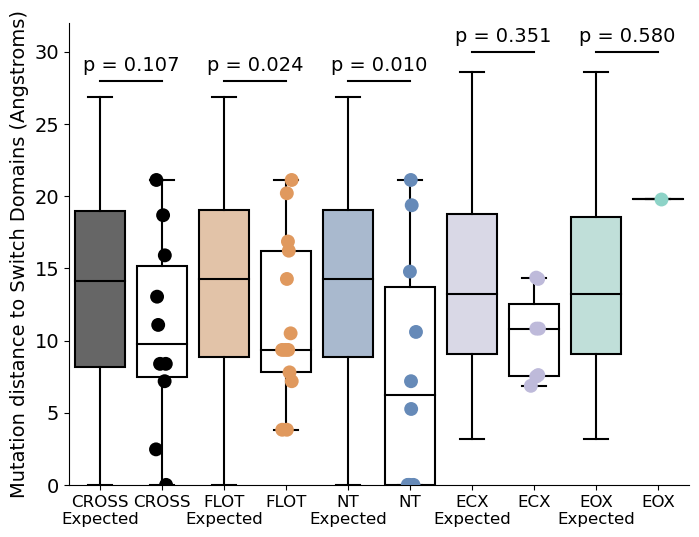

In [149]:
fig, ax = plt.subplots(figsize=(8, 6))

PROPS = {
    'boxprops':{'facecolor':'none', 'edgecolor':'black'},
    'medianprops':{'color':'black'},
    'whiskerprops':{'color':'black'},
    'capprops':{'color':'black'}
}


g = sns.boxplot(data = combined, x = "label", y = "score"
                , palette = ["k", "w", "#E0995E", "w", "#668AB8", "w", "#bebada", "w",  "#8dd3c7", "w"], showfliers = False)
for patch in ax.patches:
    r, g1, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g1, b, 0.6))

g2 = sns.stripplot(data = combined2, x = "label", y = "score", palette=["w", "k","w", "#E0995E", "w","#668AB8", "w", "#bebada", "w", "#8dd3c7"], size = 10)

x1, x2 = 0, 1  
y, h, col = 28, 0, 'k'
plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c=col)
plt.text((x1+x2)*.5, y+h+0.4, "p = 0.107", ha='center', va='bottom', color=col, size = 14)


x1, x2 = 2, 3  
y, h, col = 28, 0, 'k'
plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c=col)
plt.text((x1+x2)*.5, y+h+0.4, "p = 0.024", ha='center', va='bottom', color=col, size = 14)

x1, x2 = 4, 5  
y, h, col = 28, 0, 'k'
plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c=col)
plt.text((x1+x2)*.5, y+h+0.4, "p = 0.010", ha='center', va='bottom', color=col, size = 14)

x1, x2 = 6, 7  
y, h, col = 30, 0, 'k'
plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c=col)
plt.text((x1+x2)*.5, y+h+0.4, "p = 0.351", ha='center', va='bottom', color=col, size = 14)

x1, x2 = 8, 9  
y, h, col = 30, 0, 'k'
plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c=col)
plt.text((x1+x2)*.5, y+h+0.4, "p = 0.580", ha='center', va='bottom', color=col, size = 14)


g.set_xlabel("")
g.set_xticklabels(["CROSS\nExpected", "CROSS", "FLOT\nExpected", "FLOT", "NT\nExpected", "NT", "ECX\nExpected", "ECX", "EOX\nExpected", "EOX"], size = 12)

g.set_ylabel("Mutation distance to Switch Domains (Angstroms)", size = 14)
g.set_yticklabels([0,5,10,15,20,25,30,35,40], size = 14)
#ax.set_yscale("symlog")
ax.set_ylim(0, 32)
sns.despine()

plt.savefig("RAC1_switchI_distance.pdf", bbox_inches = "tight")

In [119]:
!pwd

/Users/davidshorthouse/OneDrive - University College London/Project_Work/Milan_Jo/Milan_Updated_data/RAC1_analysis


In [120]:
s_nt = d_nt.run_section(
    RAC1_gene, 
    lookup=switch1_lookup, 
    statistics=BinomTest()   # Here we specify the statistical test to use
)

TypeError: expected str, bytes or os.PathLike object, not NoneType

In [144]:
s_dist_ecx.get_pvalues()

{'MC_Mean_glob_k3_pvalue': 0.35136486351364865,
 'MC_Median_glob_k3_pvalue': 0.31396860313968605,
 'CDF_MC_glob_k3_pvalue': 0.47695230476952305}

In [145]:
s_dist_eox.get_pvalues()

{'MC_Mean_glob_k3_pvalue': 0.5797420257974203,
 'MC_Median_glob_k3_pvalue': 0.5677432256774323,
 'CDF_MC_glob_k3_pvalue': 0.5637436256374363}